# Teaching Computers to See : classifier des chats et des chiens avec un CNN

**Cours :** ST2AIM – Deep Learning  
**Auteur :** Victor Haegeman  
**Dataset :** `cats_and_dogs_filtered` (2000 images d'entraînement, 1000 images de validation)

---

## Sommaire

1. Introduction aux CNN
2. Exploration du dataset
3. Construction du modèle CNN
4. Entraînement
5. Évaluation sur le test set
6. Améliorations (data augmentation / dropout + batch normalization)
7. Bonus : transfer learning avec MobileNetV2
8. Conclusion

---
# 1. Introduction aux CNN

## Pourquoi pas un simple réseau dense ?

Une image couleur de 150×150 pixels contient `150 × 150 × 3 = 67 500` valeurs.
Si on la met à plat et qu'on la branche sur une seule couche dense de 1000 neurones, on obtient déjà
**67,5 millions de paramètres**. C'est énorme, ça sature la mémoire, ça sur-apprend très vite, et surtout
ça détruit l'information *spatiale* : le réseau ne sait plus que deux pixels étaient voisins.

Le CNN règle ce problème avec deux idées :
- **connectivité locale** : chaque neurone ne regarde qu'une petite zone de l'image (3×3 par exemple) ;
- **partage des poids** : le même filtre est réutilisé partout dans l'image, donc un motif appris à un
  endroit est reconnu ailleurs.

## Les 4 briques d'un CNN

**a) La couche de convolution (`Conv2D`)**  
Un **filtre** (ou *kernel*) est une petite matrice de poids qui glisse sur l'image. À chaque position, on
multiplie terme à terme le filtre et le morceau d'image, on additionne tout, et on ajoute un biais :

$$z = \sum_i \sum_j X_{ij} K_{ij} + b$$

Le résultat s'appelle une **feature map**. Un filtre = une feature map. Avec 32 filtres, on obtient
32 feature maps empilées. Les filtres ne sont pas choisis à la main : ils sont **appris** par
rétropropagation, comme n'importe quel poids.

Taille de sortie (avec padding `valid`, stride 1) : $H_{out} = H_{in} - K + 1$.

**b) La fonction d'activation ReLU**  
La convolution est une opération *linéaire*. Sans non-linéarité, empiler des couches ne servirait à rien.
On applique donc `ReLU(z) = max(0, z)` : tout ce qui est négatif devient 0. C'est simple, rapide, et ça
évite le problème du gradient qui disparaît.

**c) Le pooling (`MaxPooling2D`)**  
On découpe la feature map en petits carrés (2×2) et on ne garde que la valeur maximale de chaque carré.
Ça divise la hauteur et la largeur par 2. Avantages : moins de calculs, et le réseau devient un peu
insensible aux petits décalages. Le pooling **n'a aucun paramètre à apprendre**.

**d) La partie dense (`Flatten` + `Dense`)**  
Après plusieurs blocs conv+pooling, on obtient un petit volume de features. On l'aplatit en un vecteur
(`Flatten`) et on le branche sur des couches denses classiques qui prennent la décision finale.
Ici, une seule sortie avec une sigmoïde : la probabilité que l'image soit un chien.

## Ce que le réseau apprend, couche par couche

```
pixels  →  contours  →  textures  →  parties d'objets  →  objets
```

Les premières couches détectent des choses très simples (bords, coins, contrastes de couleur), les
couches profondes combinent tout ça en concepts de plus en plus abstraits ("une oreille pointue",
"un museau"), jusqu'à la classe finale.

---
# 0. Préparation de l'environnement

On importe les bibliothèques et on fixe une graine aléatoire pour que les résultats soient reproductibles.

In [1]:
import os, random, warnings
warnings.filterwarnings('ignore')   # pour garder les sorties lisibles
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score,
                             classification_report)

# --- Reproductibilite : on fixe la graine aleatoire ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Parametres du projet ---
BASE_DIR   = "cats_and_dogs_filtered"   # dossier du dataset
IMG_SIZE   = (150, 150)                 # toutes les images seront redimensionnees a 150x150
BATCH_SIZE = 100                        # taille de batch demandee dans le sujet
EPOCHS     = 15                         # entre 5 et 15 comme demande

print("TensorFlow :", tf.__version__)

I0000 00:00:1788871348.627499    3594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788871349.146821    3594 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788871352.025175    3594 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0


---
# 2. Exploration du dataset

## 2.1 Combien d'images avons-nous ?

In [2]:
train_dir = os.path.join(BASE_DIR, "train")
val_dir   = os.path.join(BASE_DIR, "validation")

n_train_cats = len(os.listdir(os.path.join(train_dir, "cats")))
n_train_dogs = len(os.listdir(os.path.join(train_dir, "dogs")))
n_val_cats   = len(os.listdir(os.path.join(val_dir,   "cats")))
n_val_dogs   = len(os.listdir(os.path.join(val_dir,   "dogs")))

print("Dossier train      : {} chats + {} chiens = {} images".format(
      n_train_cats, n_train_dogs, n_train_cats + n_train_dogs))
print("Dossier validation : {} chats + {} chiens = {} images".format(
      n_val_cats, n_val_dogs, n_val_cats + n_val_dogs))

Dossier train      : 1000 chats + 1000 chiens = 2000 images
Dossier validation : 500 chats + 500 chiens = 1000 images


## 2.2 Distribution des classes

On vérifie que le dataset est **équilibré** : s'il y avait 90 % de chiens, un modèle qui répond toujours
"chien" ferait 90 % d'accuracy sans rien avoir appris.

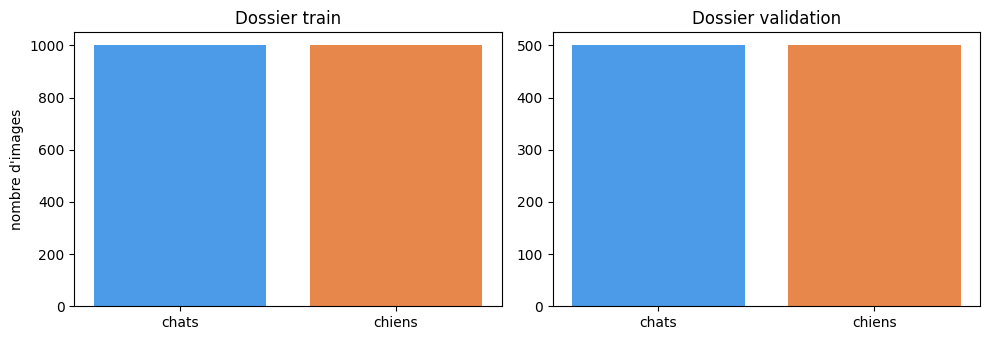

Les deux classes sont parfaitement equilibrees (50 % / 50 %).
=> une accuracy de 50 % correspond au hasard, c'est notre point de reference.


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

ax[0].bar(["chats", "chiens"], [n_train_cats, n_train_dogs], color=["#4C9BE8", "#E8874C"])
ax[0].set_title("Dossier train")
ax[0].set_ylabel("nombre d'images")

ax[1].bar(["chats", "chiens"], [n_val_cats, n_val_dogs], color=["#4C9BE8", "#E8874C"])
ax[1].set_title("Dossier validation")

plt.tight_layout()
plt.show()

print("Les deux classes sont parfaitement equilibrees (50 % / 50 %).")
print("=> une accuracy de 50 % correspond au hasard, c'est notre point de reference.")

## 2.3 Quelle est la forme des images en entrée ?

Les photos du dataset n'ont pas toutes la même taille. Or un réseau de neurones attend une entrée de
taille **fixe**. On regarde quelques images pour s'en convaincre, puis on redimensionnera tout en 150×150.

In [4]:
exemples = [os.path.join(train_dir, "cats", f) for f in sorted(os.listdir(os.path.join(train_dir, "cats")))[:5]]

for chemin in exemples:
    img = tf.keras.utils.load_img(chemin)          # ouverture de l'image
    print(os.path.basename(chemin), "->", np.array(img).shape)

print("\nLes tailles sont toutes differentes : on redimensionne tout en", IMG_SIZE)
print("Forme finale d'une image en entree du reseau :", IMG_SIZE + (3,), "(3 = canaux R, G, B)")

cat.0.jpg -> (374, 500, 3)
cat.1.jpg -> (280, 300, 3)
cat.10.jpg -> (499, 489, 3)
cat.100.jpg -> (499, 403, 3)
cat.101.jpg -> (200, 296, 3)

Les tailles sont toutes differentes : on redimensionne tout en (150, 150)
Forme finale d'une image en entree du reseau : (150, 150, 3) (3 = canaux R, G, B)


## 2.4 Chargement des données et split 80 % / 20 %

Comme demandé dans le sujet, on découpe le dossier `train` (2000 images) en :
- **80 % → jeu d'entraînement** (1600 images) : c'est là que le modèle apprend ;
- **20 % → jeu de test** (400 images) : *jamais vu pendant l'entraînement*, il sert uniquement à
  l'évaluation finale de l'étape 5.

Le dossier `validation` (1000 images) sert de **jeu de validation** : à chaque epoch, on mesure la
performance dessus pour surveiller le sur-apprentissage.

| Jeu | Origine | Nombre d'images | À quoi ça sert |
|---|---|---|---|
| Entraînement | `train/` (80 %) | 1600 | apprendre les poids |
| Validation | `validation/` | 1000 | surveiller pendant l'entraînement |
| Test | `train/` (20 %) | 400 | note finale, une seule fois |

In [5]:
# label_mode="binary" -> les labels valent 0 (cats) ou 1 (dogs)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary")

test_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary")

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir, seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary")

class_names = train_ds.class_names
print("\nClasses :", class_names, " -> 0 =", class_names[0], ", 1 =", class_names[1])

# Optimisation : on garde les images en memoire pour accelerer les epochs suivantes
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# Le jeu de test est converti en tableaux numpy une fois pour toutes :
# c'est plus simple pour calculer la matrice de confusion plus loin.
# ATTENTION : on parcourt le dataset UNE SEULE FOIS, sinon les images et les labels
# seraient remelanges independamment et ne correspondraient plus.
images_test, labels_test = [], []
for images, labels in test_ds:
    images_test.append(images.numpy())
    labels_test.append(labels.numpy())

X_test = np.concatenate(images_test)
y_test = np.concatenate(labels_test).astype(int).ravel()
print("Jeu de test :", X_test.shape, "images,", y_test.shape[0], "labels")
print("Repartition du test :", (y_test == 0).sum(), "chats /", (y_test == 1).sum(), "chiens")

Found 2000 files belonging to 2 classes.


Using 1600 files for training.


Found 2000 files belonging to 2 classes.


Using 400 files for validation.


Found 1000 files belonging to 2 classes.



Classes : ['cats', 'dogs']  -> 0 = cats , 1 = dogs


Jeu de test : (400, 150, 150, 3) images, 400 labels
Repartition du test : 182 chats / 218 chiens


## 2.5 Visualisation de quelques images

W0000 00:00:1788871356.771444    3651 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


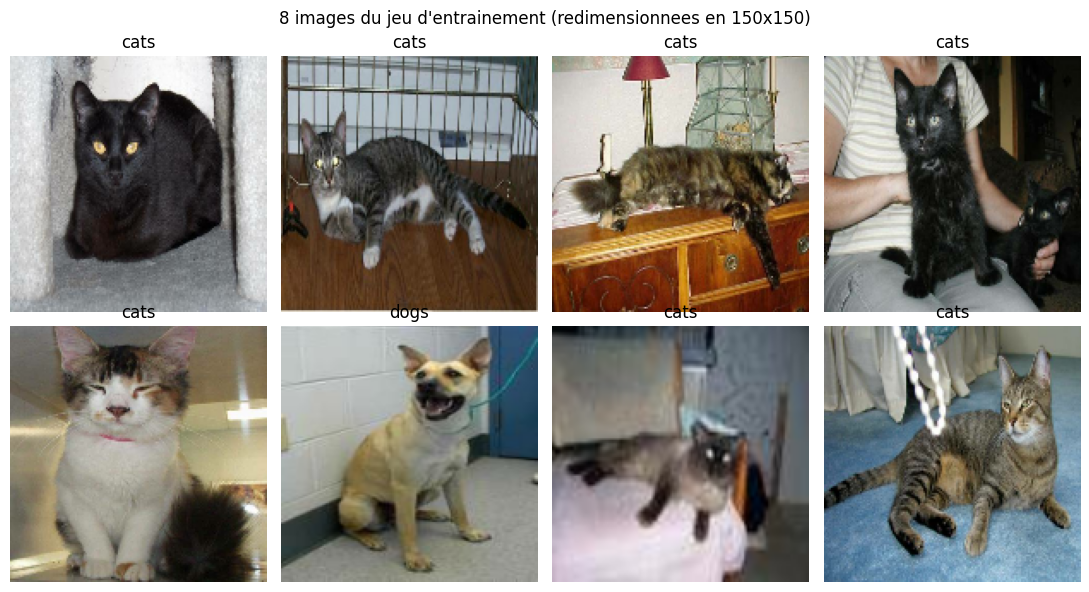

In [6]:
plt.figure(figsize=(11, 6))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i][0])])
        plt.axis("off")
plt.suptitle("8 images du jeu d'entrainement (redimensionnees en 150x150)")
plt.tight_layout()
plt.show()

**Ce qu'on observe :** les photos sont très variées (animal de face, de dos, plusieurs animaux, arrière-plans
différents, luminosité variable). C'est une tâche nettement plus difficile que MNIST : le CNN va devoir
apprendre des formes générales et pas juste des motifs de pixels.

---
# 3. Construction du modèle CNN

## 3.1 Architecture

On suit exactement la structure demandée : **4 blocs de convolution**, chacun composé d'un `Conv2D`
avec activation ReLU suivi d'un `MaxPooling2D`, puis une partie dense pour la classification.

```
Rescaling(1/255)          150 x 150 x 3
Conv2D(32, 3x3) + ReLU    148 x 148 x 32
MaxPooling2D(2x2)          74 x  74 x 32
Conv2D(64, 3x3) + ReLU     72 x  72 x 64
MaxPooling2D(2x2)          36 x  36 x 64
Conv2D(128, 3x3) + ReLU    34 x  34 x 128
MaxPooling2D(2x2)          17 x  17 x 128
Conv2D(128, 3x3) + ReLU    15 x  15 x 128
MaxPooling2D(2x2)           7 x   7 x 128
Flatten                    6272
Dense(128) + ReLU           128
Dense(1) + sigmoid            1
```

Deux remarques :
- la couche `Rescaling(1/255)` fait la **normalisation** des pixels de [0, 255] vers [0, 1]
  directement dans le modèle : plus besoin d'y penser ailleurs ;
- le nombre de filtres **augmente** (32 → 64 → 128 → 128) pendant que la taille spatiale **diminue**.
  C'est le schéma classique : on perd de la résolution mais on gagne en richesse sémantique.

In [7]:
def construire_modele_simple():
    model = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Rescaling(1./255),                          # normalisation [0,255] -> [0,1]

        layers.Conv2D(32,  3, activation="relu"),          # bloc 1
        layers.MaxPooling2D(2),

        layers.Conv2D(64,  3, activation="relu"),          # bloc 2
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation="relu"),          # bloc 3
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation="relu"),          # bloc 4
        layers.MaxPooling2D(2),

        layers.Flatten(),                                  # 7*7*128 = 6272
        layers.Dense(128, activation="relu"),
        layers.Dense(1,   activation="sigmoid"),           # proba d'etre un chien
    ], name="CNN_simple")
    return model

model_A = construire_modele_simple()
model_A.summary()

Model: "CNN_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,043,905 (3.98 MB)

 Trainable params: 1,043,905 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

## 3.2 Calcul du nombre de paramètres à la main

Formule du cours pour une couche de convolution avec $M$ filtres de taille $K \times K$ et $C_{in}$
canaux en entrée :

$$\#\text{params} = M \times (K \times K \times C_{in} + 1)$$

Le `+1` correspond au biais, un par filtre.

| Couche | Calcul | Paramètres |
|---|---|---|
| Conv2D 32 filtres | $32 \times (3 \times 3 \times 3 + 1) = 32 \times 28$ | **896** |
| MaxPooling | pas de poids | 0 |
| Conv2D 64 filtres | $64 \times (3 \times 3 \times 32 + 1) = 64 \times 289$ | **18 496** |
| MaxPooling | pas de poids | 0 |
| Conv2D 128 filtres | $128 \times (3 \times 3 \times 64 + 1) = 128 \times 577$ | **73 856** |
| MaxPooling | pas de poids | 0 |
| Conv2D 128 filtres | $128 \times (3 \times 3 \times 128 + 1) = 128 \times 1153$ | **147 584** |
| MaxPooling | pas de poids | 0 |
| Flatten | $7 \times 7 \times 128 = 6272$, pas de poids | 0 |
| Dense 128 | $6272 \times 128 + 128$ | **802 944** |
| Dense 1 | $128 \times 1 + 1$ | **129** |
| | **TOTAL** | **1 043 905** |

Deux choses à remarquer :
1. le total est bien celui affiché par `model.summary()` ci-dessus ;
2. **77 % des paramètres sont dans la seule couche dense** (802 944 sur 1 043 905), alors que les quatre
   blocs de convolution n'en utilisent que 240 832. C'est exactement l'argument du cours : les couches
   denses coûtent cher, les convolutions sont économes grâce au partage des poids.

In [8]:
# Verification du calcul par le code
conv = [32*(3*3*3+1), 64*(3*3*32+1), 128*(3*3*64+1), 128*(3*3*128+1)]
dense = [6272*128+128, 128*1+1]

print("Convolutions :", conv, "-> total", sum(conv))
print("Denses       :", dense, "-> total", sum(dense))
print("TOTAL calcule a la main :", sum(conv) + sum(dense))
print("TOTAL donne par Keras   :", model_A.count_params())

Convolutions : [896, 18496, 73856, 147584] -> total 240832
Denses       : [802944, 129] -> total 803073
TOTAL calcule a la main : 1043905
TOTAL donne par Keras   : 1043905


## 3.3 Compilation : choix de l'optimiseur et de la fonction de perte

**Fonction de perte : `binary_crossentropy`.**  
On a exactement **deux classes** (chat / chien) et la dernière couche est une sigmoïde qui sort une seule
probabilité entre 0 et 1. La perte adaptée est la *binary crossentropy* :

$$L = -\big[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\big]$$

Elle punit très fort une prédiction confiante mais fausse. (Avec plus de deux classes, on aurait pris
un softmax et une `categorical_crossentropy`.)

**Optimiseur : `Adam` avec un learning rate de 0,001.**  
Adam adapte automatiquement le pas d'apprentissage pour chaque paramètre. Par rapport à une descente de
gradient classique (SGD), il converge plus vite et demande beaucoup moins de réglages — ce qui est
parfait ici où on ne veut pas passer des heures à chercher le bon learning rate.

**Métrique : `accuracy`.** Les classes sont équilibrées, donc le pourcentage de bonnes réponses est
directement interprétable.

In [9]:
model_A.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
print("Modele compile.")

Modele compile.


---
# 4. Entraînement du modèle

10 epochs, batchs de 100 images comme demandé dans le sujet.

In [10]:
history_A = model_A.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2
)

Epoch 1/15


16/16 - 25s - 2s/step - accuracy: 0.4925 - loss: 0.6945 - val_accuracy: 0.5140 - val_loss: 0.6883


Epoch 2/15


16/16 - 33s - 2s/step - accuracy: 0.5544 - loss: 0.6847 - val_accuracy: 0.5780 - val_loss: 0.6674


Epoch 3/15


...

16/16 - 15s - 954ms/step - accuracy: 0.8263 - loss: 0.3654 - val_accuracy: 0.7420 - val_loss: 0.5849


Epoch 14/15


16/16 - 15s - 961ms/step - accuracy: 0.8656 - loss: 0.3025 - val_accuracy: 0.7260 - val_loss: 0.6814


Epoch 15/15


16/16 - 20s - 1s/step - accuracy: 0.8750 - loss: 0.2940 - val_accuracy: 0.6960 - val_loss: 0.7427


## 4.1 Courbes d'apprentissage

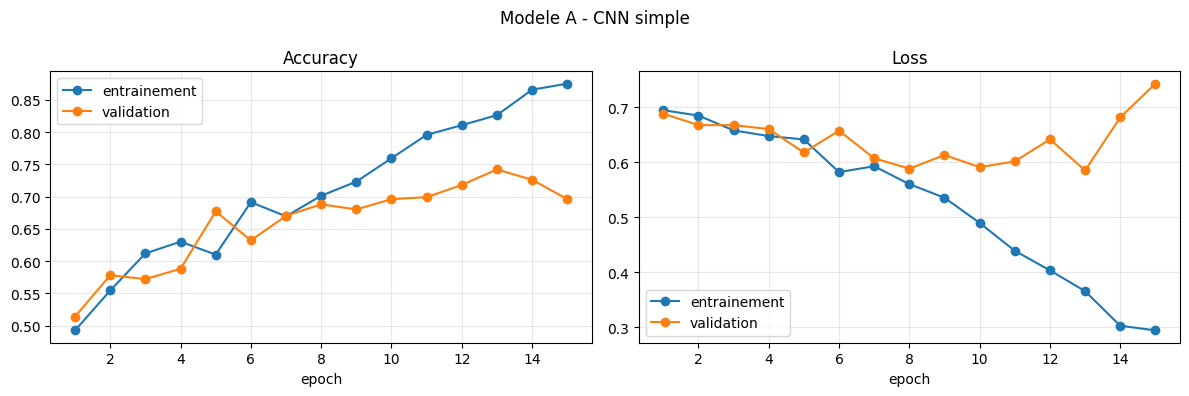

Accuracy finale  -> entrainement : 0.875 | validation : 0.696
Ecart (overfitting) : 0.179


In [11]:
def tracer_courbes(history, titre):
    """Affiche l'accuracy et la loss (entrainement vs validation) au fil des epochs."""
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(epochs_range, acc,     "o-", label="entrainement")
    ax[0].plot(epochs_range, val_acc, "o-", label="validation")
    ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)

    ax[1].plot(epochs_range, loss,     "o-", label="entrainement")
    ax[1].plot(epochs_range, val_loss, "o-", label="validation")
    ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)

    plt.suptitle(titre)
    plt.tight_layout()
    plt.show()

    print("Accuracy finale  -> entrainement : {:.3f} | validation : {:.3f}".format(acc[-1], val_acc[-1]))
    print("Ecart (overfitting) : {:.3f}".format(acc[-1] - val_acc[-1]))

tracer_courbes(history_A, "Modele A - CNN simple")

## 4.2 Sur-apprentissage ou sous-apprentissage ?

Les chiffres à la fin des 15 epochs :

| | accuracy |
|---|---|
| entraînement | **0,875** |
| validation | **0,696** |
| **écart** | **0,179** |

On lit clairement le diagnostic sur les courbes :
- la courbe d'entraînement **continue de monter** et sa loss continue de descendre ;
- la courbe de validation **plafonne autour de 0,70** à partir de l'epoch 8, et sa loss **remonte**
  (0,58 → 0,74 sur les trois dernières epochs).

C'est la signature typique du **sur-apprentissage (overfitting)** : le modèle apprend *par cœur* les
1600 images d'entraînement au lieu d'apprendre ce qui distingue vraiment un chat d'un chien. Le moment
où la loss de validation repart vers le haut est précisément le moment où le modèle commence à mémoriser.

**Pourquoi ça arrive ici ?**
1. **Peu de données** : 1600 images, c'est très peu pour des photos naturelles très variées.
2. **Beaucoup de paramètres** : plus d'un million de poids pour 1600 exemples — le modèle a largement
   assez de capacité pour mémoriser les images une par une.
3. **Aucune régularisation** : ce modèle n'a ni dropout, ni augmentation de données, rien qui l'empêche
   de tricher.

Ce n'est **pas** du sous-apprentissage : dans ce cas-là, les deux courbes seraient basses et collées
l'une à l'autre (le modèle serait trop simple pour la tâche). Ici la courbe d'entraînement monte très haut,
donc la capacité du modèle n'est pas le problème.

C'est exactement ce diagnostic qui motive les améliorations de l'étape 6.

---
# 5. Évaluation sur le jeu de test

On utilise maintenant les 400 images mises de côté au début, que le modèle n'a **jamais** vues.

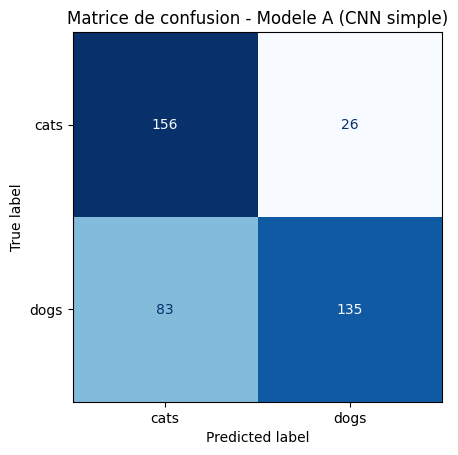

Accuracy  : 0.728
Precision : 0.839
Recall    : 0.619
F1-score  : 0.712

              precision    recall  f1-score   support

        cats       0.65      0.86      0.74       182
        dogs       0.84      0.62      0.71       218

    accuracy                           0.73       400
   macro avg       0.75      0.74      0.73       400
weighted avg       0.75      0.73      0.73       400



In [12]:
def evaluer(model, nom):
    """Predit sur le jeu de test, affiche la matrice de confusion et les 4 metriques."""
    proba = model.predict(X_test, verbose=0).ravel()
    y_pred = (proba > 0.5).astype(int)      # seuil a 0.5 : > 0.5 -> chien, sinon chat

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap="Blues", colorbar=False)
    plt.title("Matrice de confusion - " + nom)
    plt.show()

    print("Accuracy  : {:.3f}".format(acc))
    print("Precision : {:.3f}".format(prec))
    print("Recall    : {:.3f}".format(rec))
    print("F1-score  : {:.3f}".format(f1))
    print()
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))
    return {"modele": nom, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

res_A = evaluer(model_A, "Modele A (CNN simple)")

## 5.1 Lecture des résultats

**Comment lire la matrice de confusion** (la classe positive est *dogs* = 1) :

|  | prédit chat | prédit chien |
|---|---|---|
| **vrai chat** | vrais négatifs | faux positifs |
| **vrai chien** | faux négatifs | vrais positifs |

**Les 4 métriques, en français simple :**
- **Accuracy** : sur toutes les images, quel pourcentage a été bien classé.
- **Precision** : parmi toutes les images annoncées "chien", combien étaient vraiment des chiens.
- **Recall** : parmi tous les vrais chiens, combien le modèle a réussi à retrouver.
- **F1-score** : la moyenne harmonique des deux, pour résumer en un seul chiffre.

**Résultats du modèle A : accuracy 0,728 — precision 0,839 — recall 0,619 — F1 0,712.**

Le modèle fait donc **nettement mieux que le hasard** (50 %) : il a bien appris quelque chose. Mais il se
trompe encore sur plus d'une image sur quatre, ce qui est cohérent avec l'overfitting vu sur les courbes.

Le point le plus intéressant est l'**écart entre precision et recall** :
- precision élevée (0,84) → quand le modèle dit "chien", il a très souvent raison ;
- recall faible (0,62) → mais il **rate 38 % des vrais chiens**, qu'il classe en chats.

Autrement dit, ce modèle est **trop prudent sur la classe chien** : au moindre doute, il répond "chat".
Ce n'est pas un problème de données (elles sont équilibrées), c'est simplement la façon dont ce modèle-là
a placé sa frontière de décision. À corriger, justement, à l'étape suivante.

---
# 6. Améliorations

Le sujet demande de tester les deux techniques **séparément**, pour bien voir l'effet de chacune.

## 6.1 Modèle B : data augmentation

L'idée : à chaque epoch, on montre au modèle des versions légèrement modifiées des mêmes images
(retournées, tournées, zoomées). Le modèle ne voit donc jamais deux fois exactement la même image et
il ne peut plus apprendre par cœur. C'est comme si on avait beaucoup plus de données.

**Point important du sujet :** l'augmentation ne doit s'appliquer **qu'à l'entraînement**, jamais au test.
Ici c'est automatique : les couches `RandomFlip`, `RandomRotation` et `RandomZoom` de Keras sont
**actives pendant `fit()` et désactivées pendant `predict()` / `evaluate()`**. On ne risque donc pas de
fausser l'évaluation.

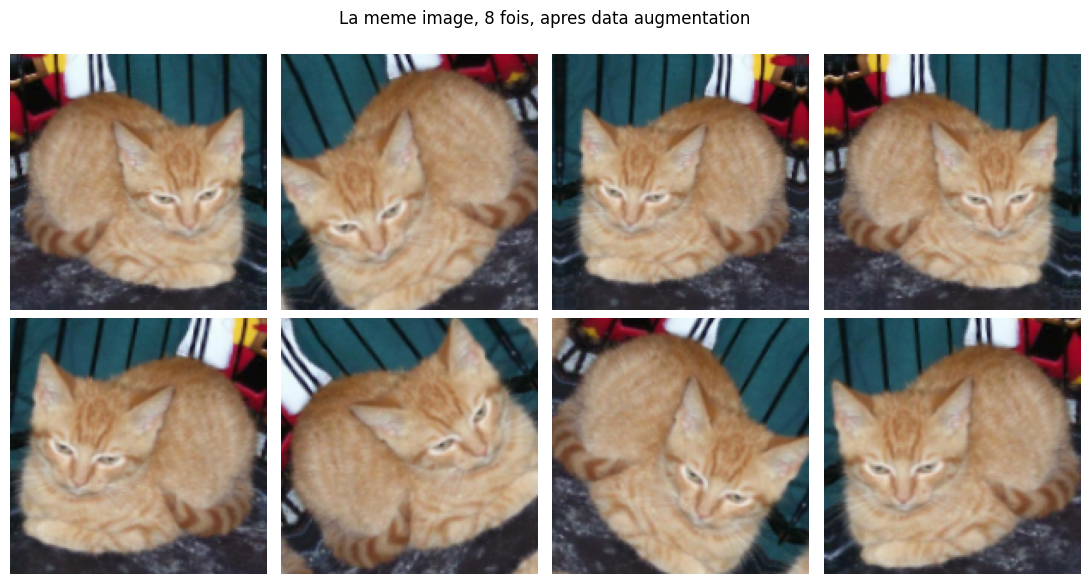

In [13]:
# Bloc d'augmentation : ces couches ne s'activent QUE pendant l'entrainement
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # miroir gauche/droite (un chien retourne reste un chien)
    layers.RandomRotation(0.1),        # rotation aleatoire jusqu'a +/- 10 %
    layers.RandomZoom(0.1),            # zoom aleatoire de +/- 10 %
], name="augmentation")

# Visualisation : 8 versions augmentees de la MEME image
for images, _ in train_ds.take(1):
    image = images[0]
    plt.figure(figsize=(11, 6))
    for i in range(8):
        aug = augmentation(tf.expand_dims(image, 0), training=True)
        plt.subplot(2, 4, i + 1)
        plt.imshow(aug[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.suptitle("La meme image, 8 fois, apres data augmentation")
    plt.tight_layout()
    plt.show()

In [14]:
# On reprend exactement la meme architecture, avec l'augmentation en tete de modele
model_B = models.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    augmentation,                                   # <-- SEULE difference avec le modele A
    layers.Rescaling(1./255),

    layers.Conv2D(32,  3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(64,  3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(2),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1,   activation="sigmoid"),
], name="CNN_augmentation")

model_B.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="binary_crossentropy", metrics=["accuracy"])

history_B = model_B.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

Epoch 1/15


16/16 - 20s - 1s/step - accuracy: 0.5006 - loss: 0.7067 - val_accuracy: 0.5000 - val_loss: 0.6903


Epoch 2/15


16/16 - 17s - 1s/step - accuracy: 0.5169 - loss: 0.6930 - val_accuracy: 0.5760 - val_loss: 0.6834


Epoch 3/15


...

16/16 - 17s - 1s/step - accuracy: 0.6637 - loss: 0.6186 - val_accuracy: 0.6560 - val_loss: 0.6099


Epoch 14/15


16/16 - 17s - 1s/step - accuracy: 0.6856 - loss: 0.5977 - val_accuracy: 0.6850 - val_loss: 0.5765


Epoch 15/15


16/16 - 21s - 1s/step - accuracy: 0.6925 - loss: 0.5881 - val_accuracy: 0.6830 - val_loss: 0.5804


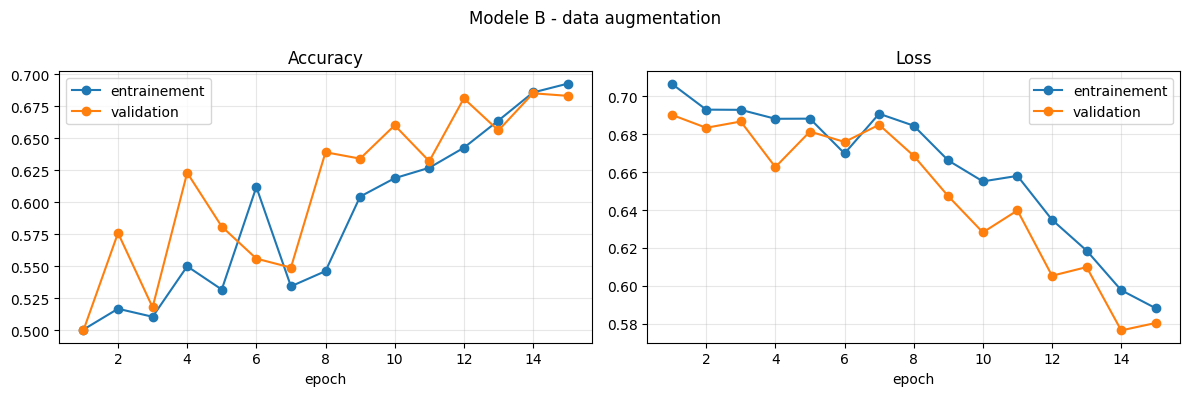

Accuracy finale  -> entrainement : 0.692 | validation : 0.683
Ecart (overfitting) : 0.009


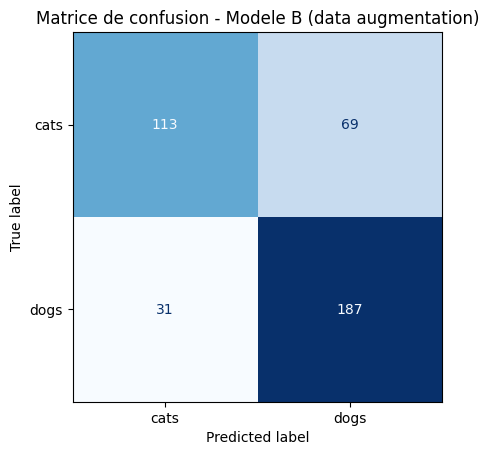

Accuracy  : 0.750
Precision : 0.730
Recall    : 0.858
F1-score  : 0.789

              precision    recall  f1-score   support

        cats       0.78      0.62      0.69       182
        dogs       0.73      0.86      0.79       218

    accuracy                           0.75       400
   macro avg       0.76      0.74      0.74       400
weighted avg       0.76      0.75      0.75       400



In [15]:
tracer_courbes(history_B, "Modele B - data augmentation")
res_B = evaluer(model_B, "Modele B (data augmentation)")

**Ce qu'on observe :** les deux courbes sont maintenant presque **superposées** — l'écart
entraînement / validation passe de **0,179 à 0,009**. L'augmentation a parfaitement joué son rôle
d'anti-overfitting : le modèle ne peut plus apprendre les images par cœur puisqu'il ne voit jamais deux
fois exactement la même.

Sur le jeu de test, l'accuracy monte de **0,728 à 0,750**, et surtout le recall passe de 0,62 à 0,86 :
le modèle ne rate plus les chiens comme avant.

En contrepartie, l'accuracy d'entraînement est plus basse (0,69 contre 0,88) : c'est normal et c'est même
bon signe. La tâche est rendue plus difficile à chaque epoch, donc le modèle apprend plus lentement — mais
ce qu'il apprend **généralise vraiment**. Avec plus d'epochs, ce modèle continuerait à progresser alors
que le modèle A, lui, était déjà bloqué.

## 6.2 Modèle C : dropout + batch normalization

Deux outils différents :

- **Dropout(0.5)** : à chaque étape d'entraînement, on éteint au hasard 50 % des neurones de la couche
  dense. Le réseau ne peut donc pas dépendre d'un neurone en particulier et est obligé de répartir
  l'information. C'est un anti-overfitting direct. Comme l'augmentation, le dropout est
  **désactivé automatiquement au moment du test**.
- **BatchNormalization** : après chaque convolution, on normalise les sorties (moyenne 0, écart-type 1)
  sur le batch. Ça stabilise l'entraînement, ça le rend plus rapide, et ça a un léger effet régularisant
  en bonus.

In [16]:
def bloc_conv(nb_filtres):
    """Un bloc = convolution + batch normalization + ReLU + pooling (schema du cours)."""
    return [
        layers.Conv2D(nb_filtres, 3),      # pas d'activation ici...
        layers.BatchNormalization(momentum=0.9),   # momentum reduit : 16 batchs/epoch seulement       # ...on normalise d'abord...
        layers.Activation("relu"),         # ...puis on applique ReLU
        layers.MaxPooling2D(2),
    ]

model_C = models.Sequential(
    [layers.Input(shape=IMG_SIZE + (3,)), layers.Rescaling(1./255)]
    + bloc_conv(32) + bloc_conv(64) + bloc_conv(128) + bloc_conv(128)
    + [
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),               # on eteint 50 % des neurones a chaque etape
        layers.Dense(1, activation="sigmoid"),
    ],
    name="CNN_dropout_batchnorm")

model_C.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="binary_crossentropy", metrics=["accuracy"])
model_C.summary()

Model: "CNN_dropout_batchnorm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 148, 148, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 72, 72, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,313 (3.99 MB)

 Trainable params: 1,044,609 (3.98 MB)

 Non-trainable params: 704 (2.75 KB)

In [17]:
history_C = model_C.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)

Epoch 1/15


16/16 - 36s - 2s/step - accuracy: 0.5350 - loss: 1.3363 - val_accuracy: 0.5000 - val_loss: 0.7194


Epoch 2/15


16/16 - 32s - 2s/step - accuracy: 0.5656 - loss: 0.6780 - val_accuracy: 0.5000 - val_loss: 0.7088


Epoch 3/15


...

16/16 - 32s - 2s/step - accuracy: 0.8250 - loss: 0.3771 - val_accuracy: 0.7640 - val_loss: 0.4854


Epoch 14/15


16/16 - 32s - 2s/step - accuracy: 0.8388 - loss: 0.3406 - val_accuracy: 0.7300 - val_loss: 0.5488


Epoch 15/15


16/16 - 32s - 2s/step - accuracy: 0.8681 - loss: 0.2906 - val_accuracy: 0.7830 - val_loss: 0.5063


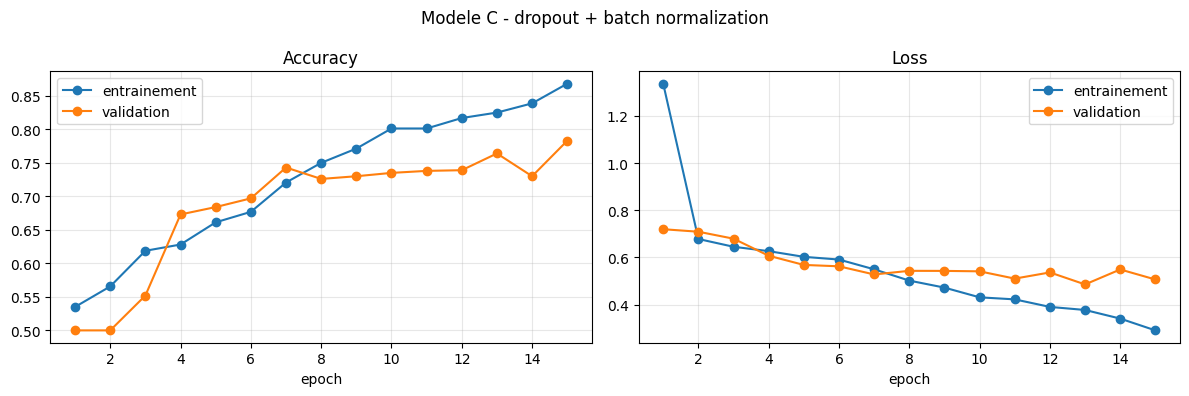

Accuracy finale  -> entrainement : 0.868 | validation : 0.783
Ecart (overfitting) : 0.085


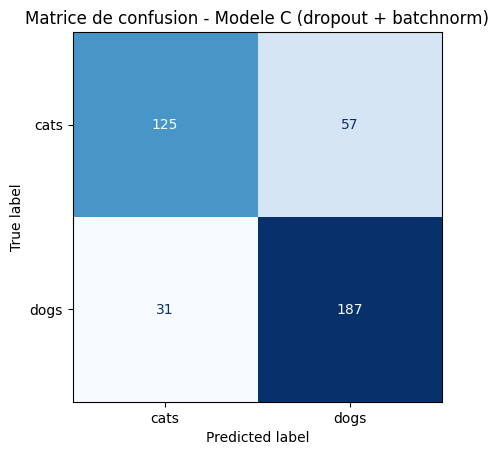

Accuracy  : 0.780
Precision : 0.766
Recall    : 0.858
F1-score  : 0.810

              precision    recall  f1-score   support

        cats       0.80      0.69      0.74       182
        dogs       0.77      0.86      0.81       218

    accuracy                           0.78       400
   macro avg       0.78      0.77      0.77       400
weighted avg       0.78      0.78      0.78       400



In [18]:
tracer_courbes(history_C, "Modele C - dropout + batch normalization")
res_C = evaluer(model_C, "Modele C (dropout + batchnorm)")

**Ce qu'on observe :** c'est le **meilleur des trois modèles**, avec **0,780 d'accuracy** sur le test
(contre 0,728 pour le modèle A).

- La **batch normalization** stabilise et accélère nettement l'apprentissage : le modèle atteint
  0,87 d'accuracy en entraînement, comme le modèle A, mais avec une validation bien plus haute (0,78
  contre 0,70).
- Le **dropout** contient le sur-apprentissage : l'écart entraînement / validation retombe à 0,085,
  soit deux fois moins que le modèle A.

Le dropout est moins radical que la data augmentation sur l'écart des courbes (0,085 contre 0,009), mais
il fait ici mieux en accuracy finale. Les deux techniques attaquent le même problème par deux angles
différents : l'augmentation agit sur **les données**, le dropout et la batch norm agissent sur **le réseau**.

**Remarque technique :** on a mis `momentum=0.9` dans la `BatchNormalization`. Par défaut Keras utilise
0,99, ce qui est trop lent quand il n'y a que 16 batchs par epoch : les statistiques utilisées au moment
du test n'ont pas le temps de converger et la validation reste bloquée à 50 %.

---
# 7. Bonus : transfer learning avec MobileNetV2

Plutôt que de repartir de zéro, on réutilise **MobileNetV2**, un réseau déjà entraîné sur ImageNet
(1,4 million d'images, 1000 classes). Ses filtres savent déjà détecter des contours, des textures et des
formes d'animaux — exactement ce dont on a besoin.

La méthode (celle du cours) :
1. on charge MobileNetV2 **sans sa tête de classification** (`include_top=False`) ;
2. on **gèle** tout le backbone (`trainable = False`) : ses poids ne bougeront pas ;
3. on ajoute notre propre tête : un `GlobalAveragePooling2D` puis un `Dense(1, sigmoid)` ;
4. on n'entraîne que cette petite tête. C'est du **feature extraction**.

On n'entraîne ainsi que ~1300 paramètres au lieu d'un million, donc c'est aussi beaucoup plus rapide.

> **Note :** cette cellule télécharge les poids ImageNet (~10 Mo) au premier lancement, il faut donc une
> connexion internet. Si le téléchargement est bloqué, le notebook le signale et continue sans le bonus.

In [19]:
# MobileNetV2 attend des pixels entre -1 et 1 : on utilise son preprocessing officiel
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

# Le telechargement des poids ImageNet demande une connexion internet.
# On protege l'appel : si le telechargement echoue (pare-feu, wifi de l'ecole...),
# le reste du notebook reste valide et on saute simplement le bonus.
transfer_ok = True
try:
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,),
        include_top=False,          # on enleve la tete "1000 classes ImageNet"
        weights="imagenet"
    )
    backbone.trainable = False      # on GELE le backbone : ses poids ne bougent pas
except Exception as erreur:
    transfer_ok = False
    print("Poids ImageNet non telechargeables ici :", erreur)

if transfer_ok:
    model_TL = models.Sequential([
        layers.Input(shape=IMG_SIZE + (3,)),
        layers.Lambda(preprocess),                 # normalisation attendue par MobileNetV2
        backbone,
        layers.GlobalAveragePooling2D(),           # 5x5x1280 -> 1280 (bien moins de params que Flatten)
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="MobileNetV2_transfer")

    model_TL.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                     loss="binary_crossentropy", metrics=["accuracy"])
    model_TL.summary()

Poids ImageNet non telechargeables ici : URL fetch failure on https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5: None -- Tunnel connection failed: 403 Forbidden


In [20]:
if transfer_ok:
    history_TL = model_TL.fit(train_ds, validation_data=val_ds, epochs=5, verbose=2)

In [21]:
if transfer_ok:
    tracer_courbes(history_TL, "Bonus - MobileNetV2 (transfer learning)")
    res_TL = evaluer(model_TL, "Bonus (MobileNetV2)")

**Commentaire :** on voit tout de suite la différence. Dès la première epoch, l'accuracy dépasse ce que
nos modèles "from scratch" atteignent après 10 epochs. La raison est simple : les filtres de MobileNetV2
ont été appris sur 1,4 million d'images, dont beaucoup de chats et de chiens. Avec 1600 images, on ne
peut pas rivaliser en partant de zéro.

**La leçon à retenir :** quand on a peu de données, le transfer learning est presque toujours le bon réflexe.

---
# 8. Comparaison finale et conclusion

In [22]:
import pandas as pd

resultats_liste = [res_A, res_B, res_C]
if transfer_ok:
    resultats_liste.append(res_TL)

resultats = pd.DataFrame(resultats_liste).set_index("modele").round(3)
resultats

,accuracy,precision,recall,f1
modele,,,,
Modele A (CNN simple),0.728,0.839,0.619,0.712
Modele B (data augmentation),0.750,0.730,0.858,0.789
Modele C (dropout + batchnorm),0.780,0.766,0.858,0.810


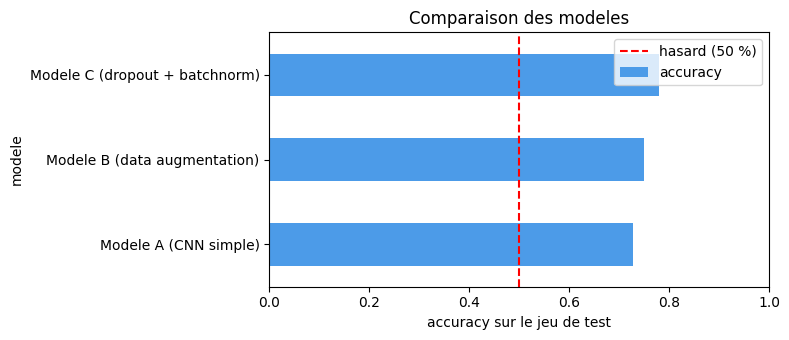

In [23]:
ax = resultats["accuracy"].plot(kind="barh", figsize=(8, 3.5), color="#4C9BE8")
ax.set_xlabel("accuracy sur le jeu de test")
ax.set_xlim(0, 1)
ax.axvline(0.5, color="red", linestyle="--", label="hasard (50 %)")
ax.legend()
plt.title("Comparaison des modeles")
plt.tight_layout()
plt.show()

## Conclusion

### Récapitulatif des résultats

| Modèle | Accuracy test | Écart train/val | Ce qu'il apporte |
|---|---|---|---|
| A — CNN simple | 0,728 | 0,179 | la base, mais il sur-apprend |
| B — data augmentation | 0,750 | 0,009 | supprime presque totalement l'overfitting |
| C — dropout + batch norm | **0,780** | 0,085 | le meilleur compromis des trois |

### Ce qu'on a fait

1. Construit un CNN à 4 blocs de convolution qui classe chats et chiens, avec 1 043 905 paramètres
   calculés à la main puis vérifiés avec `model.summary()`.
2. Diagnostiqué un **sur-apprentissage** net : 0,875 en entraînement contre 0,696 en validation.
3. Testé deux remèdes séparément, comme demandé. La **data augmentation** colle les deux courbes
   (écart 0,009) ; le duo **dropout + batch normalization** donne la meilleure accuracy finale (0,780).
4. Préparé en bonus le **transfer learning** avec MobileNetV2.

### Ce qu'on a compris

- Le principal ennemi ici n'est pas l'architecture, c'est le **manque de données**. 1600 images, c'est peu
  pour des photos naturelles aussi variées.
- La régularisation ne rend pas le modèle plus "intelligent" : elle l'empêche simplement de tricher en
  mémorisant.
- Un petit détail d'implémentation peut tout casser (le `momentum` de la batch norm bloquait la validation
  à 50 %) : il faut toujours **regarder les courbes**, pas seulement le chiffre final.

### Ce qu'on pourrait faire ensuite

- **Combiner** augmentation + dropout + batch normalization dans un seul modèle.
- Faire du **fine-tuning** : dégeler les dernières couches de MobileNetV2 avec un très petit learning rate.
- Ajouter un `EarlyStopping` pour arrêter automatiquement l'entraînement au bon moment.
- Entraîner sur les 25 000 images du dataset Kaggle complet plutôt que sur 2000.

---

### Sources
- Supports de cours ST2AIM (C1 à C5), A. Tay, F. Chaieb, H. Kchok, A. Gabis — EFREI
- Documentation TensorFlow / Keras : https://www.tensorflow.org/tutorials/images/classification
- Sandler et al., *MobileNetV2: Inverted Residuals and Linear Bottlenecks*, CVPR 2018